## Import libraries

In [2]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
import tensorflow as tf # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore

2025-03-16 18:15:38.833688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742136338.850062   10687 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742136338.854941   10687 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-16 18:15:38.872663: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load Datasets

In [3]:
df_adc = pd.read_csv("../Part1/df_adc.csv").set_index("Study Instance UID")
df_hbv = pd.read_csv("../Part1/df_hbv.csv").set_index("Study Instance_UID")
df_cor = pd.read_csv("../Part1/df_cor.csv").set_index("Study Instance UID")
df_t2w = pd.read_csv("../Part1/df_t2w.csv").set_index("Study Instance UID")
df_sag = pd.read_csv("../Part1/df_sag.csv").set_index("Study Instance UID")

## Histogram of Height, Width and channels of pics

In [4]:
def hdw(df):
    height = list()
    depth = list()
    width = list()

    for path in df['path']:
        image = sitk.ReadImage(path)
        height.append(image.GetHeight())
        depth.append(image.GetDepth())
        width.append(image.GetWidth())
    return height, depth, width

In [5]:
adc_h, adc_d, adc_w = hdw(df=df_adc)
cor_h, cor_d, cor_w = hdw(df=df_cor)
sag_h, sag_d, sag_w = hdw(df=df_sag)
t2w_h, t2w_d, t2w_w = hdw(df=df_t2w)
hbv_h, hbv_d, hbv_w = hdw(df=df_hbv)

In [6]:
def plot_hdw(h, d, w, df_name):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title(f'Histogram of height & width for {df_name}')
    plt.xlabel('height/width(No.pixel)')
    sns.histplot(h, kde=True)
    sns.histplot(w, kde=True)
    plt.legend(['height', 'width'])

    plt.subplot(1, 2, 2)
    plt.title(f"Histogram of channels for {df_name}")
    plt.xlabel("channels")
    sns.histplot(d, kde=True)

    plt.tight_layout()
    plt.show()

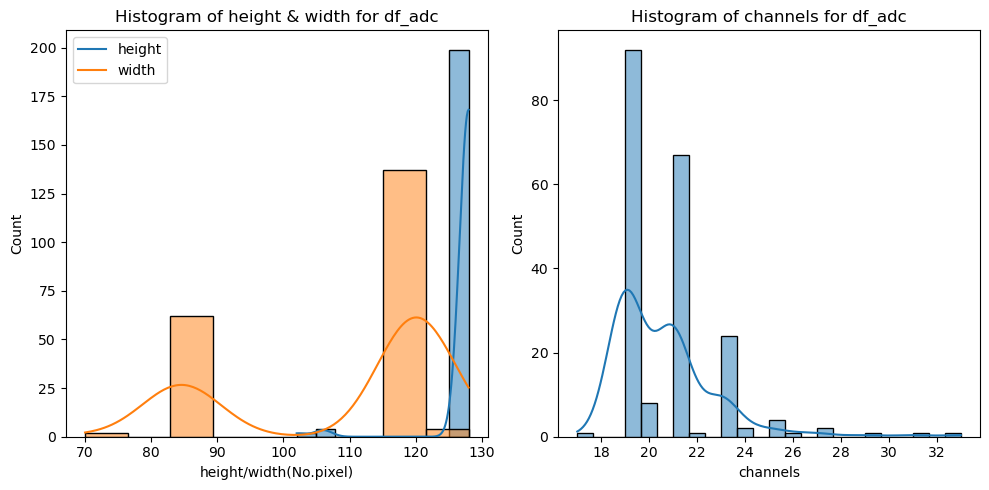

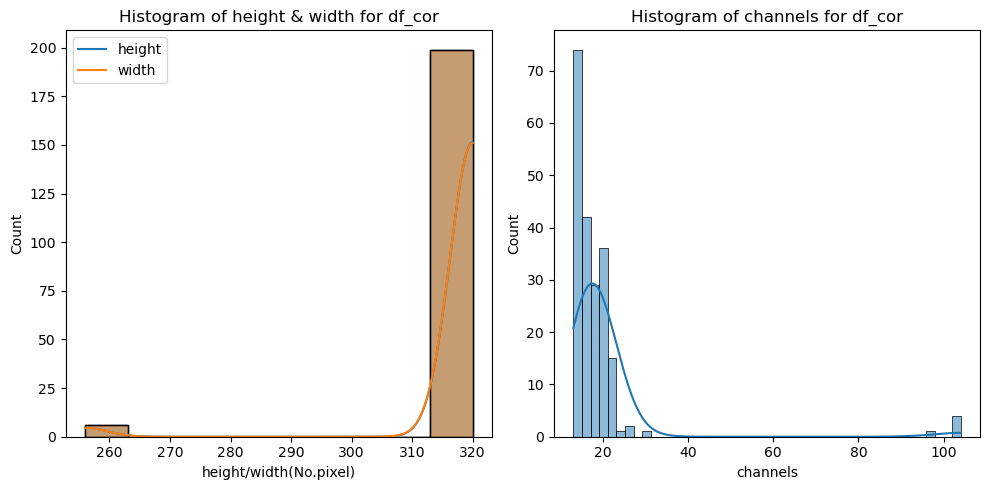

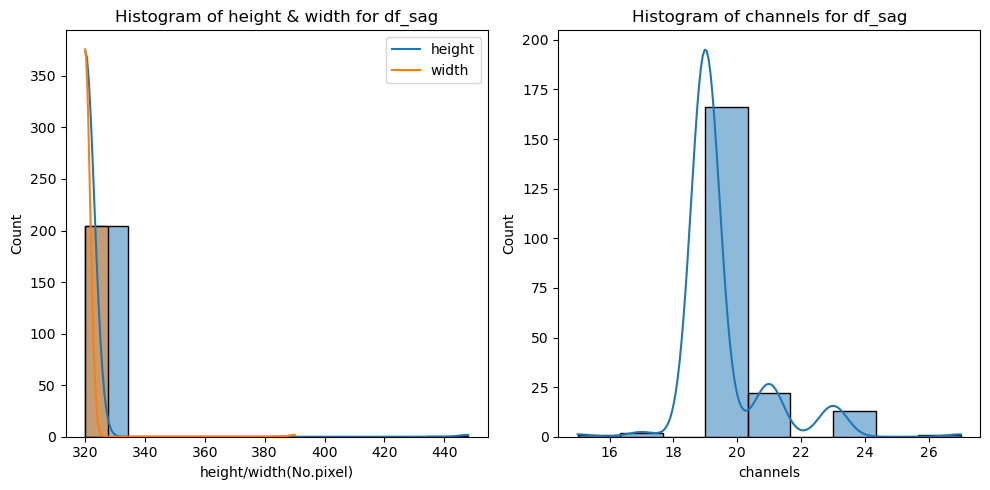

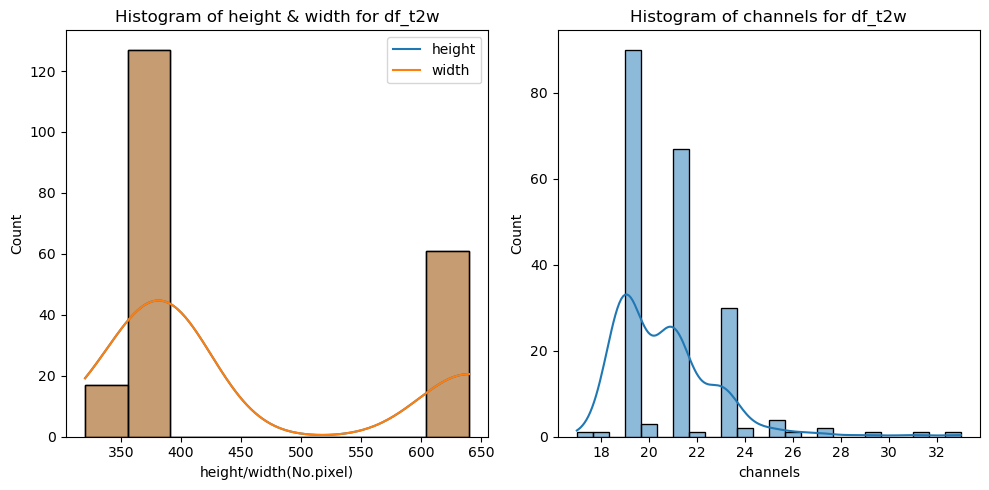

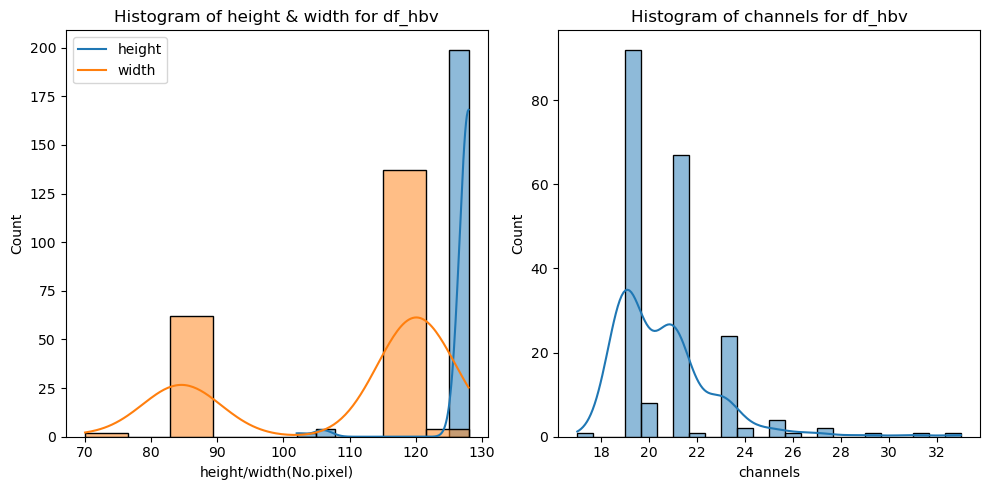

In [7]:
plot_hdw(adc_h, adc_d, adc_w, 'df_adc')
plot_hdw(cor_h, cor_d, cor_w, 'df_cor')
plot_hdw(sag_h, sag_d, sag_w, 'df_sag')
plot_hdw(t2w_h, t2w_d, t2w_w, 'df_t2w')
plot_hdw(hbv_h, hbv_d, hbv_w, 'df_hbv')

## Add Label to Dataframe

In [8]:
marksheet = pd.read_csv("marksheet.csv")
marksheet.set_index("study_id", inplace=True)
label = marksheet["case_csPCa"]
labels = []
for i in label.index:
    for j in df_adc.index:
        if i == j:
            if label[i] == "YES":
                labels.append(1)
            else:
                labels.append(0)
            continue

In [9]:
df_adc['label'] = labels
df_cor['label'] = labels
df_hbv['label'] = labels
df_t2w["label"] = labels
df_sag["label"] = labels

In [10]:
df_adc

,Manufacturer,Manufacturer's Model Name,Patient's Age,PROSTATE_VOLUME_REPORT,PSAD_REPORT,PSA_REPORT,path,label
Study Instance UID,,,,,,,,
1000001,SIEMENS,Skyra,64,102.0,0.09,8.70,Dataset_v1/10001_1000001_adc.mha,0
1000006,SIEMENS,Skyra,73,27.0,0.23,6.20,Dataset_v1/10006_1000006_adc.mha,0
1000020,SIEMENS,Skyra,43,47.0,0.11,4.60,Dataset_v1/10020_1000020_adc.mha,0
1000023,SIEMENS,TrioTim,62,37.0,0.03,1.50,Dataset_v1/10023_1000023_adc.mha,0
1000029,SIEMENS,Skyra,64,46.0,0.20,8.90,Dataset_v1/10029_1000029_adc.mha,1
...,...,...,...,...,...,...,...,...
1001475,SIEMENS,Skyra,71,44.0,0.14,5.58,Dataset_v1/11451_1001475_adc.mha,1
1001491,SIEMENS,Skyra,61,103.0,0.05,5.40,Dataset_v1/11467_1001491_adc.mha,0
1001493,SIEMENS,Skyra,49,34.0,0.13,4.30,Dataset_v1/11469_1001493_adc.mha,0


## Image Normalization

In [11]:
def rescale_images(image):
    filter = sitk.RescaleIntensityImageFilter()
    filter.SetOutputMaximum(255)
    filter.SetOutputMinimum(0)
    rescaled_image = filter.Execute(image)
    return rescaled_image

In [12]:
def show_hist_intensity(df, numbers, df_name, scaler = 'origin'):
    scaled = list()
    plt.figure(figsize=(10, 5))
    if scaler == 'origin':
        plt.title(f"Histogram of Intensity for {df_name}")
        for pic in range(numbers):
            image = sitk.ReadImage(df['path'].iloc[pic])
            rescaled_image = rescale_images(image=image)
            image_array = sitk.GetArrayFromImage(rescaled_image)
            sns.histplot(image_array[10, :, :].flatten(), kde=True, alpha=0.3)
    elif scaler == 'standard':
        plt.title(f"Histogram of Intensity for {df_name} (standard_scaled)")
        for pic in range(numbers):
            image = sitk.ReadImage(df['path'].iloc[pic])
            rescaled_image = rescale_images(image=image)
            image_array = sitk.GetArrayFromImage(rescaled_image)
            mask = np.where(image_array != 0)
            desired_img = image_array[mask]
            mean = np.mean(desired_img)
            std = np.std(desired_img)
            final_image = (image_array - mean) / std
            sns.histplot(final_image[10, :, :].flatten(), kde=True, alpha=0.3)
    elif scaler == 'minmax':
        plt.title(f"Histogram of Intensity for {df_name} (min_max)")
        for pic in range(numbers):
            image = sitk.ReadImage(df['path'].iloc[pic])
            rescaled_image = rescale_images(image=image)
            image_array = sitk.GetArrayFromImage(rescaled_image)
            min = np.min(image_array)
            max = np.max(image_array)
            final_image = (image_array - min) / (max - min)
            sns.histplot(final_image[10, :, :].flatten(), kde=True, alpha=0.3)
    plt.legend(range(numbers))
    plt.xlabel("Intensity")
    plt.tight_layout()
    plt.show()

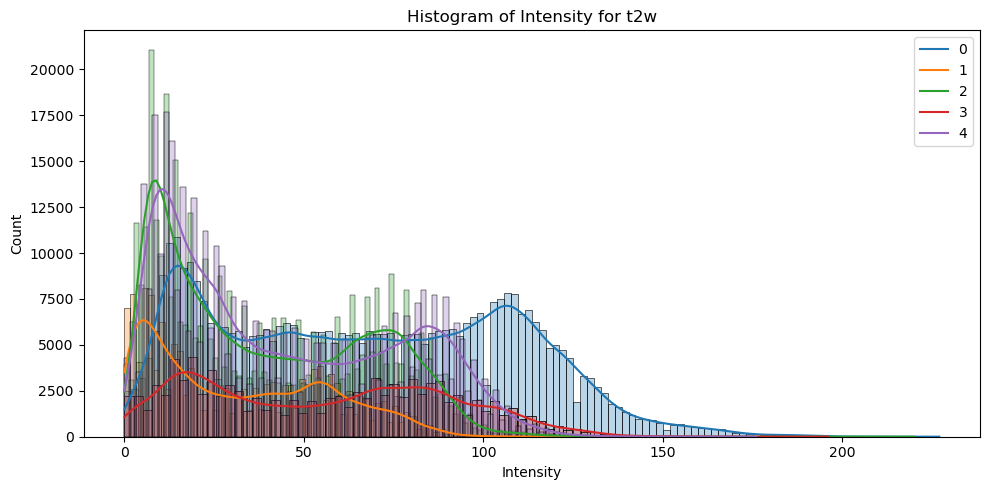

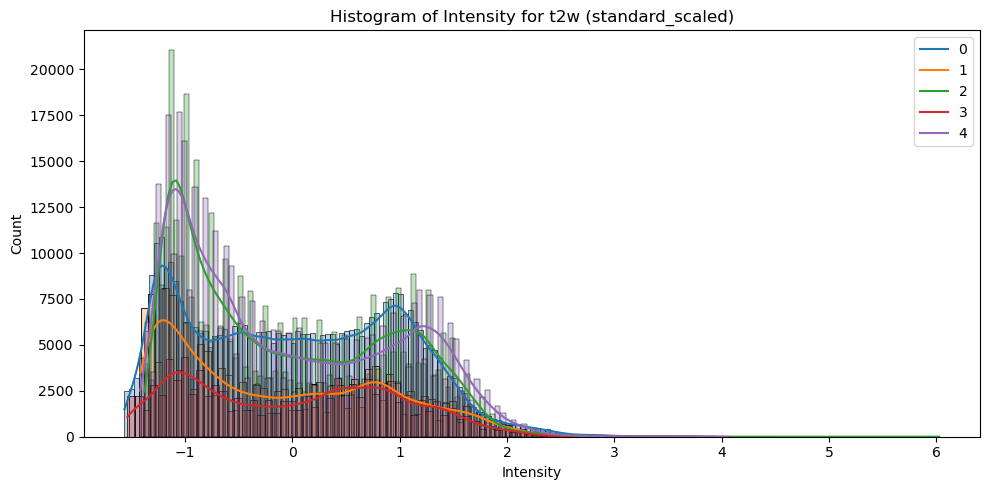

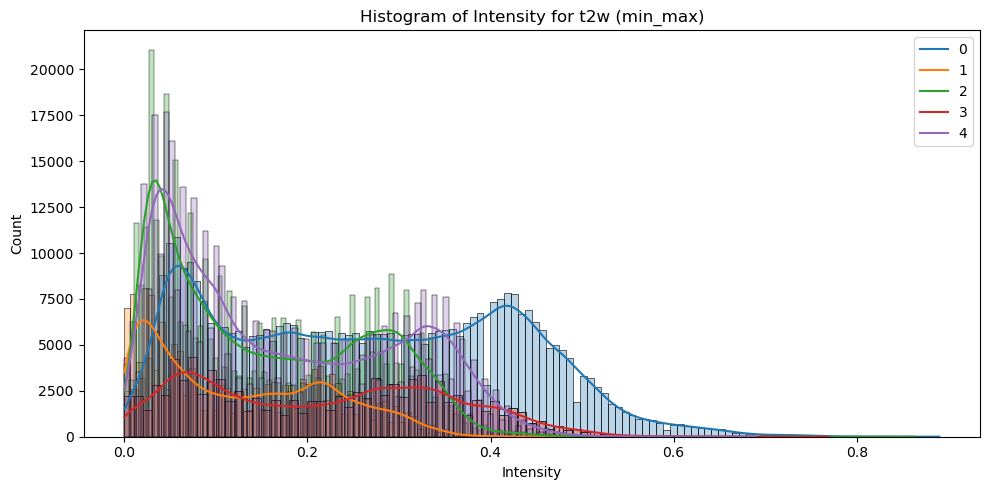

In [13]:
show_hist_intensity(df_t2w, 5, 't2w')
show_hist_intensity(df_t2w, 5, 't2w', scaler='standard')
show_hist_intensity(df_t2w, 5, 't2w', scaler='minmax')

In [14]:
def rescaler(df_name: str, df: object):
    scaler = MinMaxScaler()
    os.makedirs("Dataset_v2", exist_ok=True)
    dir = list()
    for image in df['path']:
        re_image = rescale_images(sitk.ReadImage(image))
        image_array = sitk.GetArrayFromImage(re_image)
        mask = np.where(image_array != 0)
        desired_image = image_array[mask]
        mean = np.mean(desired_image)
        std = np.std(desired_image)
        final_image = sitk.GetImageFromArray((image_array - mean) / std)
        sitk.WriteImage(image=final_image, fileName=f'Dataset_v2/{image.split('/')[-1]}')
        dir.append(f'Dataset_v2/{image.split('/')[-1]}')
    df['path'] = dir

In [15]:
rescaler('adc', df_adc)
rescaler('sag', df_sag)
rescaler('cor', df_cor)
rescaler('t2w', df_t2w)
rescaler('hbv', df_hbv)

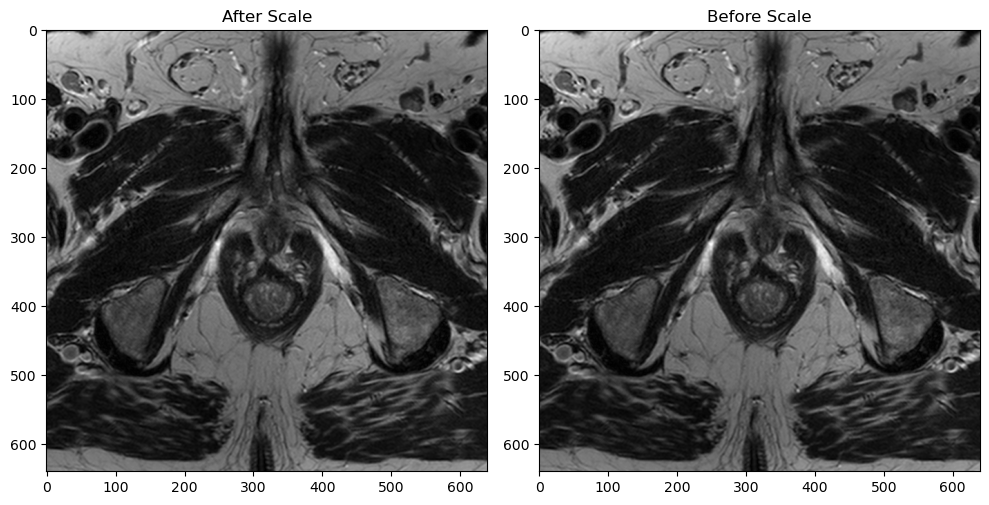

In [16]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("After Scale")
plt.imshow(sitk.GetArrayFromImage(sitk.ReadImage(df_t2w['path'].iloc[0]))[0], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Before Scale")
plt.imshow(sitk.GetArrayFromImage(sitk.ReadImage("Dataset_v2/10001_1000001_t2w.mha"))[0], cmap='gray')
plt.tight_layout()
plt.show()

In [17]:
def change_size(df):
    for pic in range(len(df['path'])):
        image = sitk.ReadImage(df['path'].iloc[pic])

        new_size = [256, 256, image.GetDepth()]

        original_size = image.GetSize()
        original_spacing = image.GetSpacing()

        new_spacing = [
            original_spacing[0] * (original_size[0] / new_size[0]),
            original_spacing[1] * (original_size[1] / new_size[1]),
            original_spacing[2]
        ]

        resample = sitk.ResampleImageFilter()
        resample.SetOutputSpacing(new_spacing)
        resample.SetSize(new_size)
        resample.SetInterpolator(sitk.sitkLinear)
        resample.SetOutputDirection(image.GetDirection())
        resample.SetOutputOrigin(image.GetOrigin())
        resample.SetDefaultPixelValue(0)

        resampled_image = resample.Execute(image)
        sitk.WriteImage(resampled_image, f'Dataset_v2/{df['path'].iloc[pic].split('/')[-1]}')

In [18]:
change_size(df_adc)
change_size(df_t2w)
change_size(df_cor)
change_size(df_hbv)
change_size(df_sag)

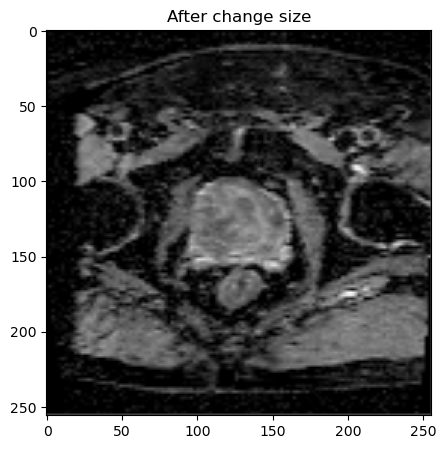

(256, 256, 21)

In [19]:
imge = sitk.ReadImage(df_adc['path'].iloc[0])
image_arr = sitk.GetArrayFromImage(imge)
plt.figure(figsize=(10, 5))
plt.title("After change size")
plt.imshow(image_arr[10], cmap='gray')
plt.show()
imge.GetSize()


## Noise Handling and Contrast Enhancement

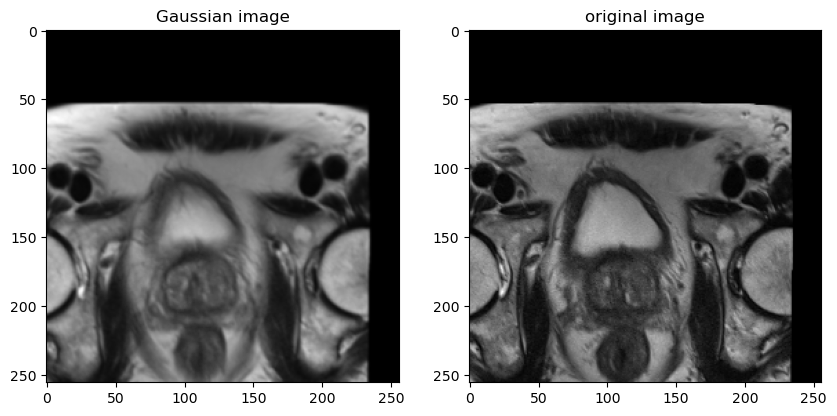

In [31]:
imge = sitk.ReadImage(df_t2w['path'].iloc[5])
gaussian_filter = sitk.SmoothingRecursiveGaussianImageFilter()
gaussian_filter.SetSigma(1)
gaussain_image = gaussian_filter.Execute(imge)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gaussian image")
plt.imshow(sitk.GetArrayFromImage(gaussain_image)[10], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("original image")
plt.imshow(sitk.GetArrayFromImage(imge)[11], cmap='gray')
plt.show()

In [32]:
image_array = sitk.GetArrayFromImage(imge)
gaussian_array = sitk.GetArrayFromImage(gaussain_image)

data_range = image_array.max() - image_array.min()

psnr_value = psnr(image_array, gaussian_array, data_range=data_range)

ssim_value, _ = ssim(image_array, gaussian_array, data_range=data_range, full=True)

print(f"SSIM value: {ssim_value}")
print(f"PSNR value: {psnr_value}")

SSIM value: 0.8947325943236758
PSNR value: 25.4631996820809


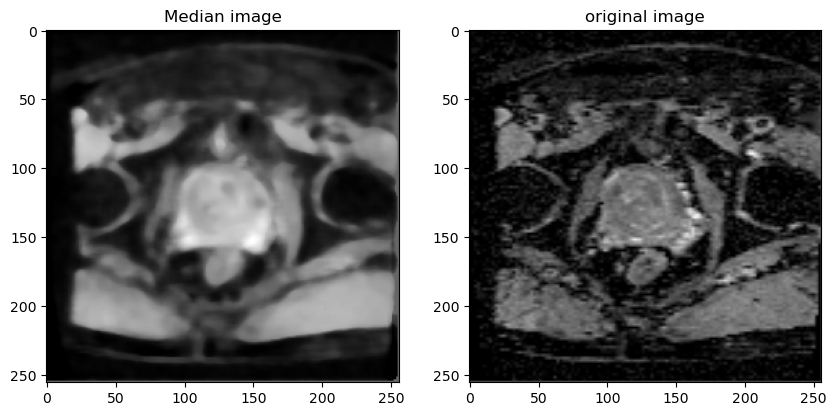

In [70]:
imge = sitk.ReadImage(df_adc['path'].iloc[0])
median_filter = sitk.MedianImageFilter()
median_filter.SetRadius(3)
median_image = median_filter.Execute(imge)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Median image")
plt.imshow(sitk.GetArrayFromImage(median_image)[11], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("original image")
plt.imshow(sitk.GetArrayFromImage(imge)[11], cmap='gray')
plt.show()

In [39]:
image_array = sitk.GetArrayFromImage(imge)
median_array = sitk.GetArrayFromImage(median_image)

data_range = image_array.max() - image_array.min()

psnr_value = psnr(image_array, median_array, data_range=data_range)

ssim_value, _ = ssim(image_array, median_array, data_range=data_range, full=True)

print(f"SSIM value: {ssim_value}")
print(f"PSNR value: {psnr_value}")

SSIM value: 0.8838700660542762
PSNR value: 26.55917925111538


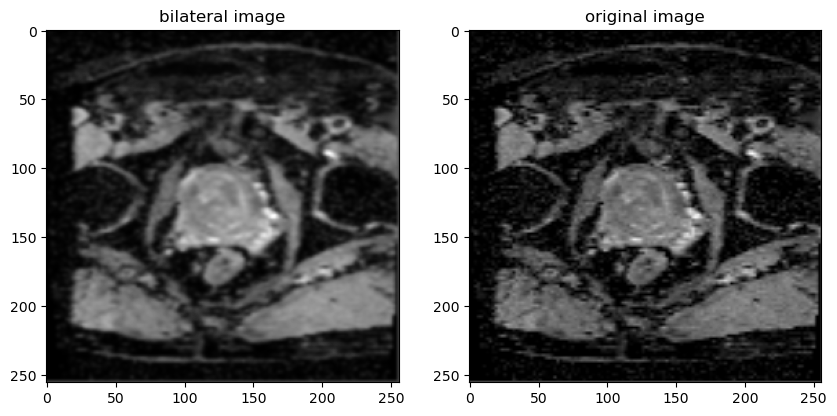

In [72]:
imge = sitk.ReadImage(df_adc['path'].iloc[0])
bilateral_filter = sitk.BilateralImageFilter()
bilateral_filter.SetDomainSigma(0.5)
bilateral_filter.SetRangeSigma(3)
bilateral_image = bilateral_filter.Execute(imge)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("bilateral image")
plt.imshow(sitk.GetArrayFromImage(bilateral_image)[11], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("original image")
plt.imshow(sitk.GetArrayFromImage(imge)[11], cmap='gray')
plt.show()

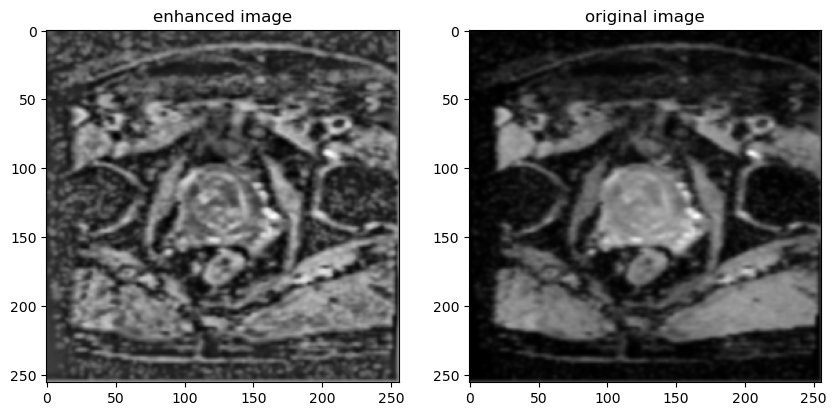

In [74]:
imge = sitk.ReadImage(df_adc['path'].iloc[0])

clahe_filter = sitk.AdaptiveHistogramEqualizationImageFilter()
clahe_filter.SetAlpha(0.5)
clahe_filter.SetBeta(0.5)
enhanced_image = clahe_filter.Execute(bilateral_image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("enhanced image")
plt.imshow(sitk.GetArrayFromImage(enhanced_image)[11], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("original image")
plt.imshow(sitk.GetArrayFromImage(bilateral_image)[11], cmap='gray')
plt.show()

In [25]:
image_array = sitk.GetArrayFromImage(imge)
enhanced_array = sitk.GetArrayFromImage(enhanced_image)

data_range = median_array.max() - median_array.min()

psnr_value = psnr(image_array, enhanced_array, data_range=data_range)

ssim_value, _ = ssim(image_array, enhanced_array, data_range=data_range, full=True)

print(f"SSIM value: {ssim_value}")
print(f"PSNR value: {psnr_value}")

SSIM value: -0.024531197206771285
PSNR value: 13.944494817287222


In [ ]:
def ahe(df):
    os.makedirs('Dataset_v3', exist_ok=True)
    for pic in range(len(df['path'])):
        image = sitk.ReadImage(df['path'].iloc[pic])
        ahe_filter = sitk.AdaptiveHistogramEqualizationImageFilter()
        ahe_filter.SetAlpha(0.5)
        ahe_filter.SetBeta(0.5)
        enhanced_image = ahe_filter.Execute(image)
        sitk.WriteImage(enhanced_image, f'Dataset_v3/{df["path"].iloc[pic].split("/")[-1]}')
        df["path"].iloc[pic] = f'Dataset_v3/{df["path"].iloc[pic].split("/")[-1]}'

In [27]:
ahe(df_t2w)
ahe(df_sag)
ahe(df_cor)
ahe(df_adc)
ahe(df_hbv)

In [28]:
df_adc.to_csv('df_adc.csv')
df_cor.to_csv('df_cor.csv')
df_sag.to_csv('df_sag.csv')
df_t2w.to_csv('df_t2w.csv')
df_hbv.to_csv('df_hbv.csv')